<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/Labo_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Useful starting lines
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style("darkgrid")

import warnings
warnings.filterwarnings('ignore')

# Sklearn import
from sklearn.preprocessing import MinMaxScaler # Normalization
from sklearn.linear_model import LinearRegression # Regression linear model
from sklearn.model_selection import train_test_split # Splitting the data set
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error # Metrics for errors
from sklearn.model_selection import KFold # Cross validation

In [ ]:
# Load the data
url = 'https://media.githubusercontent.com/media/michalis0/Business-Intelligence-and-Analytics/master/data/Advertising.csv'
data = pd.read_csv(url)

# Afficher les 5 premières lignes
print(data.head())
print("Shape:", data.shape)

   id     TV  Radio  Newspaper  Sales
0   1  230.1   37.8       69.2   22.1
1   2   44.5   39.3       45.1   10.4
2   3   17.2   45.9       69.3    9.3
3   4  151.5   41.3       58.5   18.5
4   5  180.8   10.8       58.4   12.9
Shape: (200, 5)


In [ ]:
print(data.corr())

                 id        TV     Radio  Newspaper     Sales
id         1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV         0.017715  1.000000  0.054809   0.056648  0.782224
Radio     -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper -0.154944  0.056648  0.354104   1.000000  0.228299
Sales     -0.051616  0.782224  0.576223   0.228299  1.000000


In [ ]:
X = data[['TV']]  # DataFrame format
y = data[['Sales']]

Intercept: [7.29249377]
Coefficient: [[0.04600779]]
R2 Score: 0.6763151577939721
MAE: 2.505418178966003
MSE: 10.18618193453022


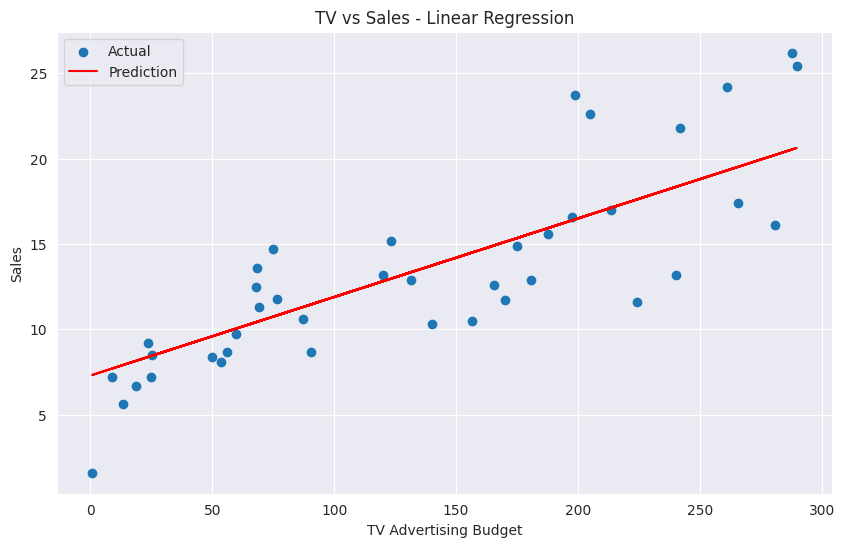

In [ ]:
# 1. Create X, y
X = data[['TV']]  # DataFrame format
y = data[['Sales']]

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, shuffle=True
)

# 3. Create the linear regression model
model = LinearRegression(fit_intercept=True)

# Fit model
model.fit(X_train, y_train)

# 4. Model parameters
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

# 5. Model performance
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# 6. Plot the regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Prediction')
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales - Linear Regression")
plt.legend()
plt.show()


==== Test avec la variable : TV ====
R2: 0.6763151577939721
MAE: 2.505418178966003
MSE: 10.18618193453022


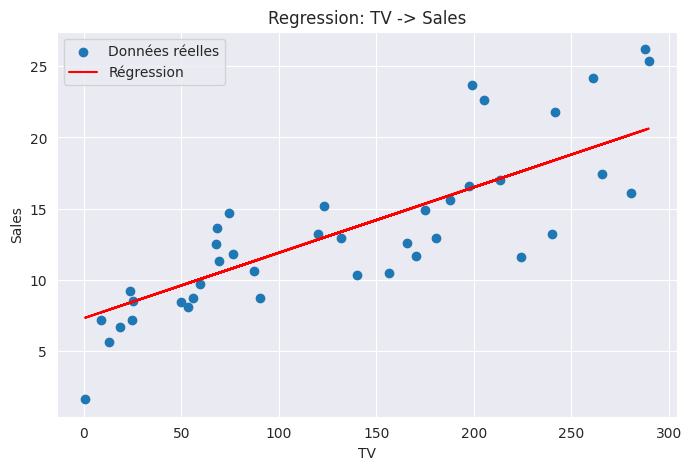


==== Test avec la variable : Radio ====
R2: 0.22981692241915952
MAE: 3.7170557782348
MSE: 24.23723303713214


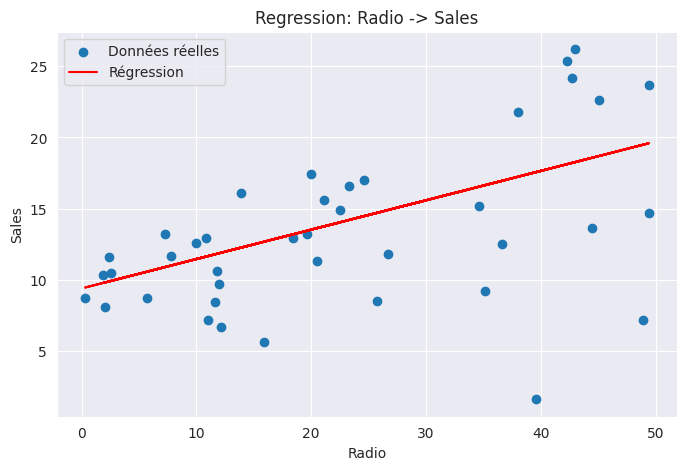


==== Test avec la variable : Newspaper ====
R2: -0.021217489521373478
MAE: 4.695793806469637
MSE: 32.13714634300907


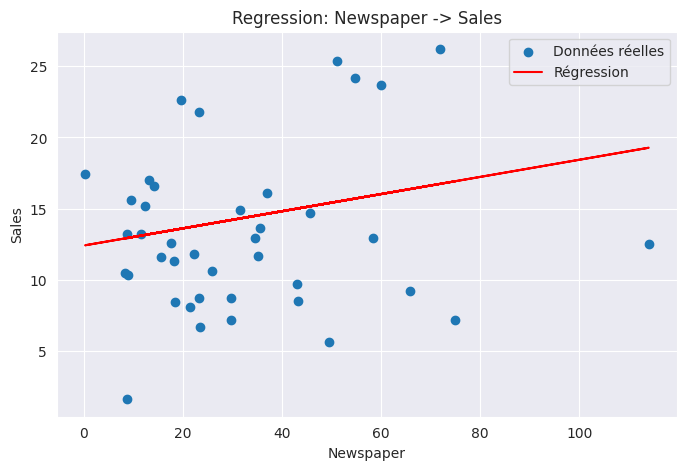

In [ ]:
def test_single_feature(feature_name):
    print(f"\n==== Test avec la variable : {feature_name} ====")

    X = data[[feature_name]]
    y = data[['Sales']]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, shuffle=True)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print("R2:", r2)
    print("MAE:", mae)
    print("MSE:", mse)

    # Tracer la droite de régression
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, label='Données réelles')
    plt.plot(X_test, y_pred, color='red', label='Régression')
    plt.xlabel(feature_name)
    plt.ylabel('Sales')
    plt.title(f'Regression: {feature_name} -> Sales')
    plt.legend()
    plt.show()

# Tester chaque variable seule
for feature in ['TV', 'Radio', 'Newspaper']:
    test_single_feature(feature)

In [ ]:
# 1. Use all features
X_all = data[['TV', 'Radio', 'Newspaper']]
y_all = data[['Sales']]

# 2. Split the data
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=0, shuffle=True
)

# 3. Create the linear regression model
model_all = LinearRegression(fit_intercept=True)

# Fit model
model_all.fit(X_train_all, y_train_all)

# 4. Print the model parameters
print("Intercept:", model_all.intercept_)
print("Coefficients:", model_all.coef_)

# 5. Model performance
y_pred_all = model_all.predict(X_test_all)

r2_all = r2_score(y_test_all, y_pred_all)
mae_all = mean_absolute_error(y_test_all, y_pred_all)
mse_all = mean_squared_error(y_test_all, y_pred_all)

print("R2 Score (all):", r2_all)
print("MAE (all):", mae_all)
print("MSE (all):", mse_all)

Intercept: [2.99489303]
Coefficients: [[ 0.04458402  0.19649703 -0.00278146]]
R2 Score (all): 0.8601145185017868
MAE (all): 1.3617813502090275
MSE (all): 4.402118291449685


In [ ]:
# Supposons que tu as ça pour le modèle avec seulement TV
r2_tv = r2_score(y_test, y_pred)
mae_tv = mean_absolute_error(y_test, y_pred)
mse_tv = mean_squared_error(y_test, y_pred)

# Différences
print("Amélioration R2:", r2_all - r2_tv)
print("Réduction MAE:", mae_tv - mae_all)
print("Réduction MSE:", mse_tv - mse_all)

Amélioration R2: 0.18379936070781466
Réduction MAE: 1.1436368287569756
Réduction MSE: 5.784063643080535


In [ ]:
#pour quiz1


# Fonction pour tester chaque variable (TV, Radio, Newspaper) et obtenir les scores R²
def test_single_feature(feature_name):
    X = data[[feature_name]]
    y = data[['Sales']]

    # Séparation des données en jeu d'entraînement et jeu de test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, shuffle=True)

    # Création du modèle de régression linéaire
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prédiction sur le jeu de test
    y_pred = model.predict(X_test)

    # Calcul du score R²
    r2 = r2_score(y_test, y_pred)

    return r2

# Tester chaque variable et afficher les résultats R²
r2_tv = test_single_feature('TV')
r2_radio = test_single_feature('Radio')
r2_newspaper = test_single_feature('Newspaper')

# Affichage des résultats
print("R² pour TV:", r2_tv)
print("R² pour Radio:", r2_radio)
print("R² pour Newspaper:", r2_newspaper)

# Comparaison des résultats
if r2_tv > r2_radio and r2_tv > r2_newspaper:
    print("\nLa meilleure variable pour prédire les ventes est : TV")
elif r2_radio > r2_tv and r2_radio > r2_newspaper:
    print("\nLa meilleure variable pour prédire les ventes est : Radio")
else:
    print("\nLa meilleure variable pour prédire les ventes est : Newspaper")


R² pour TV: 0.6763151577939721
R² pour Radio: 0.22981692241915952
R² pour Newspaper: -0.021217489521373478

La meilleure variable pour prédire les ventes est : TV


In [ ]:
#pour quiz2




# Calcul du R² pour le modèle multivarié (toutes les variables)
X_all = data[['TV', 'Radio', 'Newspaper']]  # Toutes les variables
y_all = data[['Sales']]

# Séparation des données
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=0, shuffle=True)

# Création du modèle de régression linéaire
model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

# Prédiction et calcul du R² pour le modèle multivarié
y_pred_all = model_all.predict(X_test_all)
r2_all = r2_score(y_test_all, y_pred_all)

# R² du meilleur modèle univarié de la Partie 2 (ici, supposons que c'est le modèle avec 'TV')
r2_best_univariate = r2_tv  # Remplacez r2_tv par la variable contenant le meilleur R² de la Partie 2

# Calcul de la différence absolue
improvement = abs(r2_all - r2_best_univariate)

# Affichage de l'amélioration arrondie à deux décimales
print(f"Amélioration R² : {improvement:.2f}")


Amélioration R² : 0.18
